In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import time

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Arial'

# ── Parameters ────────────────────────────────────────────────────────────────
CFG = {
    'S1': 0.5,  'S2': 1.0,  'S3': 1.0,   # healthy bistable window
    'd_aSyn': 15.0, 'K': 8.5, 'n': 4.0,
    'k1': 0.72,  'k2': 0.72,
    'k3': 0.7,   'k4': 0.7,  'k5': 2.7,
    'k6': 1.0,   'k7': 0.5,  'k8': 1.0,  'ERST': 2.0,
    'k9': 2.0,   'k10': 10.0,'k11': 0.4, 'k12': 7.0,  'mTORT': 1.0,
    'k13': 2.0,  'k14': 4.0, 'k15': 1.0,
    'k16': 10.0, 'k17': 0.6, 'Jbe': 1.0, 'Beclin1T': 1.0,
    'k18': 1.0,  'k19': 2.0, 'k20': 2.0,
    'k21': 2.0,  'k22': 4.5, 'Jca': 0.04,'CaspasesT': 1.0,
}

# ── Transport ─────────────────────────────────────────────────────────────────
TR = {
    'DROS':      6.5e6,
    'DERS':      3.6e4,
    'DmTOR':     36.0,
    'DBeclin1':  5.4e4,
    'DCaspases': 7.2e4,
    'vlyso':     7200.0,  # mTOR retrograde
    'vB':        36.0,    # Beclin1 anterograde
    'vC':        36.0,    # Caspases anterograde
}

# ── Yang healthy ODE SS (from homogeneous validation) ────────────────────────
SS_HEALTHY = {
    'ROS':      2.493,
    'aSyn':     1.815,
    'ERS':      0.952,
    'mTOR':     0.668,
    'Beclin1':  0.762,
    'Caspases': 0.118,
}

# ── Axon geometry ─────────────────────────────────────────────────────────────
L   = 1000.0    # µm — single axon for now
Nx  = 100
dx  = L / Nx
x   = np.linspace(0, L, Nx)

# IC shape parameters
lambda_R   = 0.005   # µm⁻¹  — ROS decay length from synapse
L_eff_B1   = 251.0   # µm    — Beclin1 effective transport length
lambda_C   = 500.0   # µm    — Caspase pool decay
k_active_C = 0.01    # fraction of Caspase pool active at t=0

species_names = ['ROS', 'aSyn*', 'ERS', 'mTOR', 'Beclin1', 'Caspases']
print(f"Setup complete. L={L} µm, Nx={Nx}, dx={dx} µm")

Setup complete. L=1000.0 µm, Nx=100, dx=10.0 µm


In [23]:
def build_ic(L, Nx, CFG, TR, SS_HEALTHY,
             lambda_R=0.005, L_eff_B1=251.0,
             lambda_C=500.0, k_active_C=0.01):
    """
    Biologically motivated asymmetric IC for axon of length L.

    ROS:      exponential peaking at synapse (x=L)
    aSyn*:    tiny linear gradient toward synapse
    ERS:      zero (no stress signal at t=0)
    mTOR:     uniform at healthy ODE SS
    Beclin1:  exponential decay from soma (x=0)
    Caspases: small fraction of decaying pool
    """
    x = np.linspace(0, L, Nx)

    # ROS: peaks at synapse — mitochondrial ROS source at terminal
    ROS_ic  = SS_HEALTHY['ROS'] * np.exp(-lambda_R * (L - x))

    # aSyn*: tiny seed gradient — years of slow transport accumulation
    aSyn_ic = 0.1 * (x / L)

    # ERS: zero — no aggregate burden at t=0
    ERS_ic  = np.zeros(Nx)

    # mTOR: uniform — retrograde transport redistributes efficiently
    mTOR_ic = np.full(Nx, SS_HEALTHY['mTOR'])

    # Beclin1: decays from soma — transport/degradation balance
    B1_ic   = SS_HEALTHY['Beclin1'] * np.exp(-x / L_eff_B1)

    # Caspases: small active fraction of decaying pool
    CaspT_x = np.exp(-x / lambda_C)
    Casp_ic = k_active_C * CaspT_x

    y0 = np.concatenate([ROS_ic, aSyn_ic, ERS_ic,
                         mTOR_ic, B1_ic,  Casp_ic])
    return y0, x


y0, x = build_ic(L, Nx, CFG, TR, SS_HEALTHY)

# ── Print IC ranges ────────────────────────────────────────────────────────────
print(f"\nInitial Condition Ranges (L={L} µm)")
print(f"{'Species':<12}  {'Soma (x=0)':>12}  {'Mid (x=L/2)':>12}  "
      f"{'Synapse (x=L)':>14}  {'Gradient'}")
print("─" * 70)


Initial Condition Ranges (L=1000.0 µm)
Species         Soma (x=0)   Mid (x=L/2)   Synapse (x=L)  Gradient
──────────────────────────────────────────────────────────────────────


In [24]:
def pde_rhs(t, y_flat, p, TR, dx, Nx):
    """
    Full spatial PDE — Yang kinetics + diffusion + advection.
    Species order: [ROS | aSyn* | ERS | mTOR | Beclin1 | Caspases]
    """
    ROS  = np.maximum(y_flat[0*Nx:1*Nx], 0)
    A    = np.maximum(y_flat[1*Nx:2*Nx], 0)
    ERS  = np.maximum(y_flat[2*Nx:3*Nx], 0)
    mTOR = np.maximum(y_flat[3*Nx:4*Nx], 0)
    B1   = np.maximum(y_flat[4*Nx:5*Nx], 0)
    Casp = np.maximum(y_flat[5*Nx:6*Nx], 0)

    # ── Spatial operators ─────────────────────────────────────────────────────
    def laplacian(u):
        d2u       = np.zeros(Nx)
        d2u[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        d2u[0]    = (u[1]  - u[0])  / dx**2   # Neumann BC left
        d2u[-1]   = (u[-2] - u[-1]) / dx**2   # Neumann BC right
        return d2u

    def upwind(u, v):
        du = np.zeros(Nx)
        if v > 0:       # anterograde: backward difference
            du[1:]  = -(v/dx) * (u[1:] - u[:-1])
            du[0]   = 0.0
        elif v < 0:     # retrograde: forward difference
            du[:-1] = -(v/dx) * (u[1:] - u[:-1])
            du[-1]  = 0.0
        return du

    # ── Reaction terms ────────────────────────────────────────────────────────
    Hill   = A**p['n'] / (p['K']**p['n'] + A**p['n'])

    f_ROS  = (p['k1']*(1 + p['S1'] + p['d_aSyn']*Hill)
              - p['k2']*ROS*p['S2'])

    # aSyn*: immobile, aggregation as BOUNDARY FLUX at x=L (grid-independent)
    f_A          = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR
    f_A[-1]     += p['k3']*ROS[-1]*p['S3']   # extra aggregation at synapse

    f_ERS  = (p['k6']*A*p['k7']*(p['ERST'] - ERS)
              - p['k8']*ERS)

    MT_avail = np.maximum(p['mTORT'] - mTOR, 0)
    f_mTOR = ((p['k9'] + p['k10']*ERS)*MT_avail
              - (p['k11'] + p['k12']*B1)*mTOR)

    BT_avail = np.maximum(p['Beclin1T'] - B1, 0)
    act_B    = ((p['k13'] + p['k14']*ERS)
                * BT_avail / (p['Jbe'] + BT_avail + 1e-12))
    inact_B  = ((p['k15'] + p['k16']*Casp + p['k17']*mTOR)
                * B1 / (p['Jbe'] + B1 + 1e-12))
    f_B1   = act_B - inact_B

    CT      = p['CaspasesT'] * np.exp(-np.linspace(0, L, Nx) / 500.0)
    act_C   = ((p['k18'] + p['k19']*ERS + p['k20']*mTOR)
               * (CT - Casp) / (p['Jca'] + CT - Casp + 1e-12))
    inact_C = ((p['k21'] + p['k22']*B1)
               * Casp / (p['Jca'] + Casp + 1e-12))
    f_Casp = act_C - inact_C

    # ── Assemble: transport + reaction ───────────────────────────────────────
    dROS   = TR['DROS']      * laplacian(ROS)  + f_ROS
    dA     =                                     f_A
    dERS   = TR['DERS']      * laplacian(ERS)  + f_ERS
    dmTOR  = (TR['DmTOR']    * laplacian(mTOR)
              + upwind(mTOR, -TR['vlyso'])     + f_mTOR)
    dB1    = (TR['DBeclin1'] * laplacian(B1)
              + upwind(B1,    TR['vB'])        + f_B1)
    dCasp  = (TR['DCaspases']* laplacian(Casp)
              + upwind(Casp,  TR['vC'])        + f_Casp)

    return np.concatenate([dROS, dA, dERS, dmTOR, dB1, dCasp])

print("PDE RHS defined.")

PDE RHS defined.


In [25]:
T_sim   = 500.0
# Replace the t_eval definition in Cell 4 with this:

t_eval = np.unique(np.concatenate([
    np.linspace(0,   10,  50),
    np.linspace(10,  100, 100),
    np.linspace(100, 500, 100),
]))
print(f"Running PDE simulation...")
print(f"  L={L} µm, Nx={Nx}, T={T_sim}h, S1={CFG['S1']}")
print(f"  Solver: Radau, rtol=1e-5, atol=1e-7")

t0  = time.time()
sol = solve_ivp(
    pde_rhs, (0, T_sim), y0,
    args        = (CFG, TR, dx, Nx),
    method      = 'Radau',
    t_eval      = t_eval,
    rtol        = 1e-5,
    atol        = 1e-7,
    max_step    = 1.0,
    dense_output= False
)
elapsed = time.time() - t0

print(f"\nDone. Wall time: {elapsed:.1f}s")
print(f"Solver success: {sol.success}")
if not sol.success:
    print(f"Message: {sol.message}")

# ── Extract SS (mean of last 10 time points) ──────────────────────────────────
def extract_field(sol, sp_idx, Nx, t_idx=-1):
    return sol.y[sp_idx*Nx:(sp_idx+1)*Nx, t_idx]

SS = {}
for i, sp in enumerate(species_names):
    # Check convergence: compare last 10 time points
    last10 = sol.y[i*Nx:(i+1)*Nx, -10:]
    drift  = np.max(np.abs(last10[:,-1] - last10[:,0]))
    SS[sp] = sol.y[i*Nx:(i+1)*Nx, -1]
    print(f"  {sp:<12}: max drift in last 10 steps = {drift:.2e} µM  "
          f"{'✓ converged' if drift < 1e-3 else '⚠ still drifting'}")

Running PDE simulation...
  L=1000.0 µm, Nx=100, T=500.0h, S1=0.5
  Solver: Radau, rtol=1e-5, atol=1e-7

Done. Wall time: 7.2s
Solver success: True
  ROS         : max drift in last 10 steps = 2.22e-16 µM  ✓ converged
  aSyn*       : max drift in last 10 steps = 2.22e-16 µM  ✓ converged
  ERS         : max drift in last 10 steps = 1.11e-16 µM  ✓ converged
  mTOR        : max drift in last 10 steps = 1.11e-16 µM  ✓ converged
  Beclin1     : max drift in last 10 steps = 1.11e-16 µM  ✓ converged
  Caspases    : max drift in last 10 steps = 1.39e-17 µM  ✓ converged


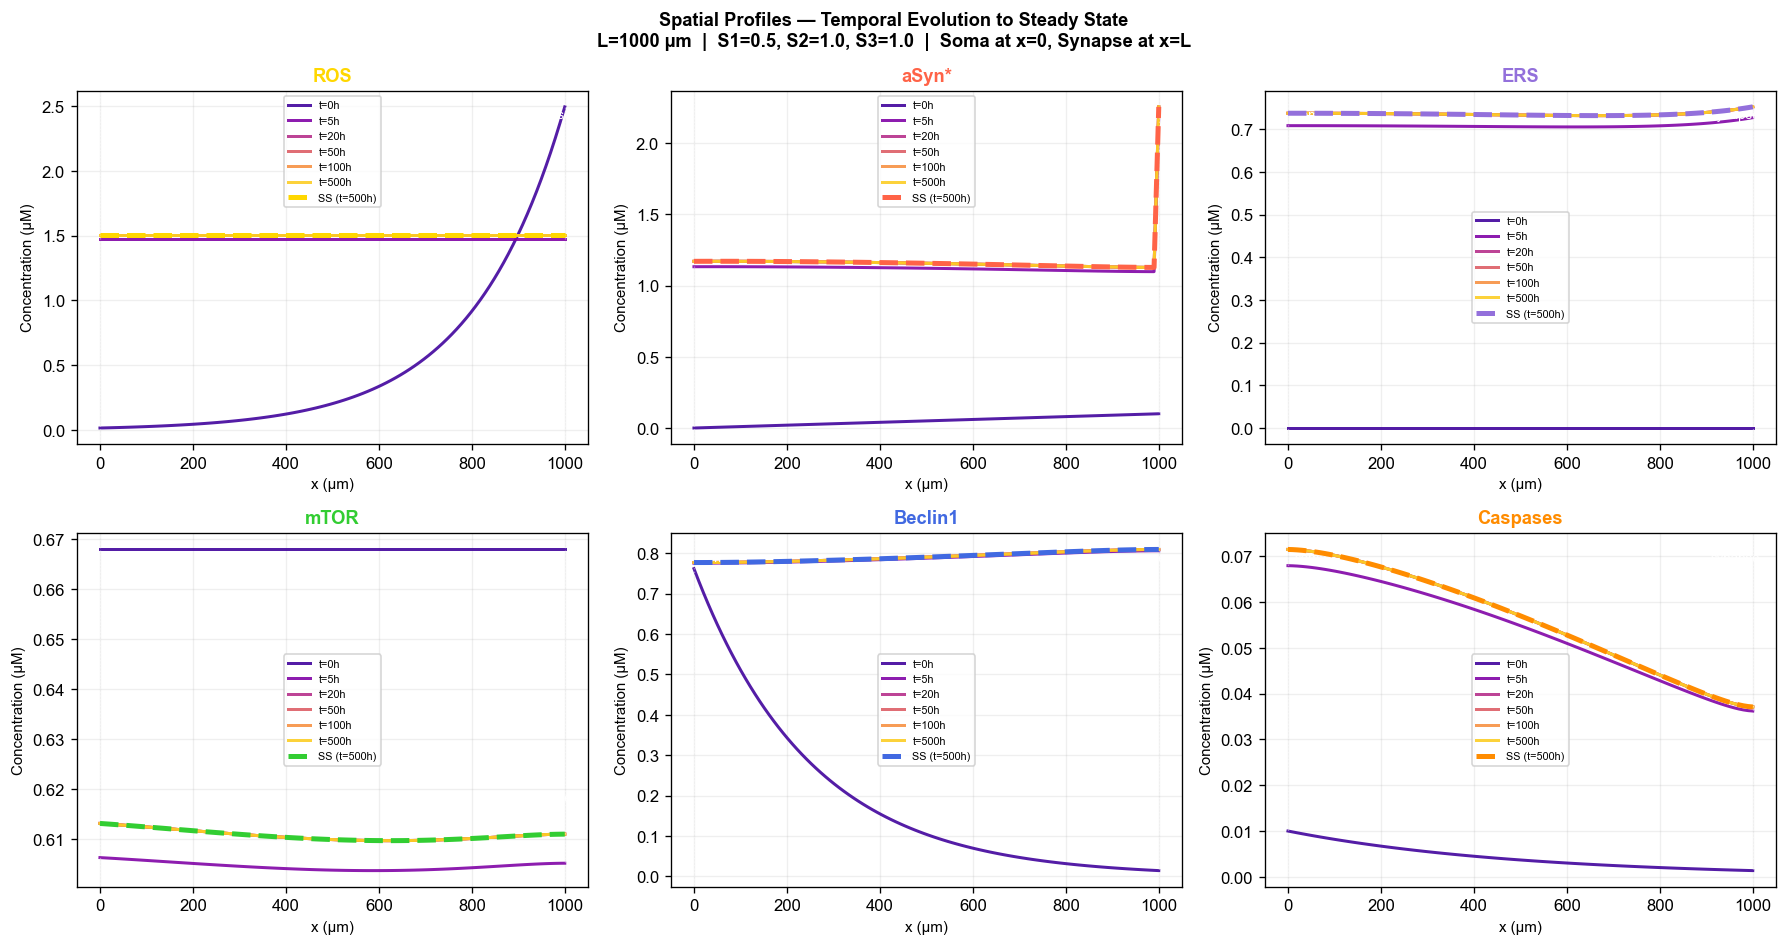

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

t_snaps    = [0, 5, 20, 50, 100, 500]
t_indices  = [np.argmin(np.abs(sol.t - ts)) for ts in t_snaps]
colors_t   = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snaps)))
colors_sp  = ['gold','tomato','mediumpurple',
              'limegreen','royalblue','darkorange']

for i, (sp, col) in enumerate(zip(species_names, colors_sp)):
    ax = axes[i]
    for ti, (t_idx, ts) in enumerate(zip(t_indices, t_snaps)):
        field = sol.y[i*Nx:(i+1)*Nx, t_idx]
        ax.plot(x, field,
                color=colors_t[ti], lw=1.8,
                alpha=0.9, label=f't={ts}h')

    # Highlight SS
    ax.plot(x, SS[sp], color=col, lw=3,
            ls='--', label='SS (t=500h)', zorder=5)

    ax.axvline(0,   color='white', ls=':', lw=0.8, alpha=0.4)
    ax.axvline(L,   color='white', ls=':', lw=0.8, alpha=0.4)
    ax.text(15,   ax.get_ylim()[1]*0.92, 'soma',    color='white', fontsize=8)
    ax.text(L-90, ax.get_ylim()[1]*0.92, 'synapse', color='white', fontsize=8)
    ax.set_title(sp, fontsize=11, fontweight='bold', color=col)
    ax.set_xlabel('x (µm)', fontsize=9)
    ax.set_ylabel('Concentration (µM)', fontsize=9)
    ax.legend(fontsize=6.5, loc='best')
    ax.grid(alpha=0.2)

plt.suptitle(
    f'Spatial Profiles — Temporal Evolution to Steady State\n'
    f'L={L:.0f} µm  |  S1={CFG["S1"]}, S2={CFG["S2"]}, S3={CFG["S3"]}  |  '
    f'Soma at x=0, Synapse at x=L',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('spatial_profiles_all.png', dpi=150)
plt.show()

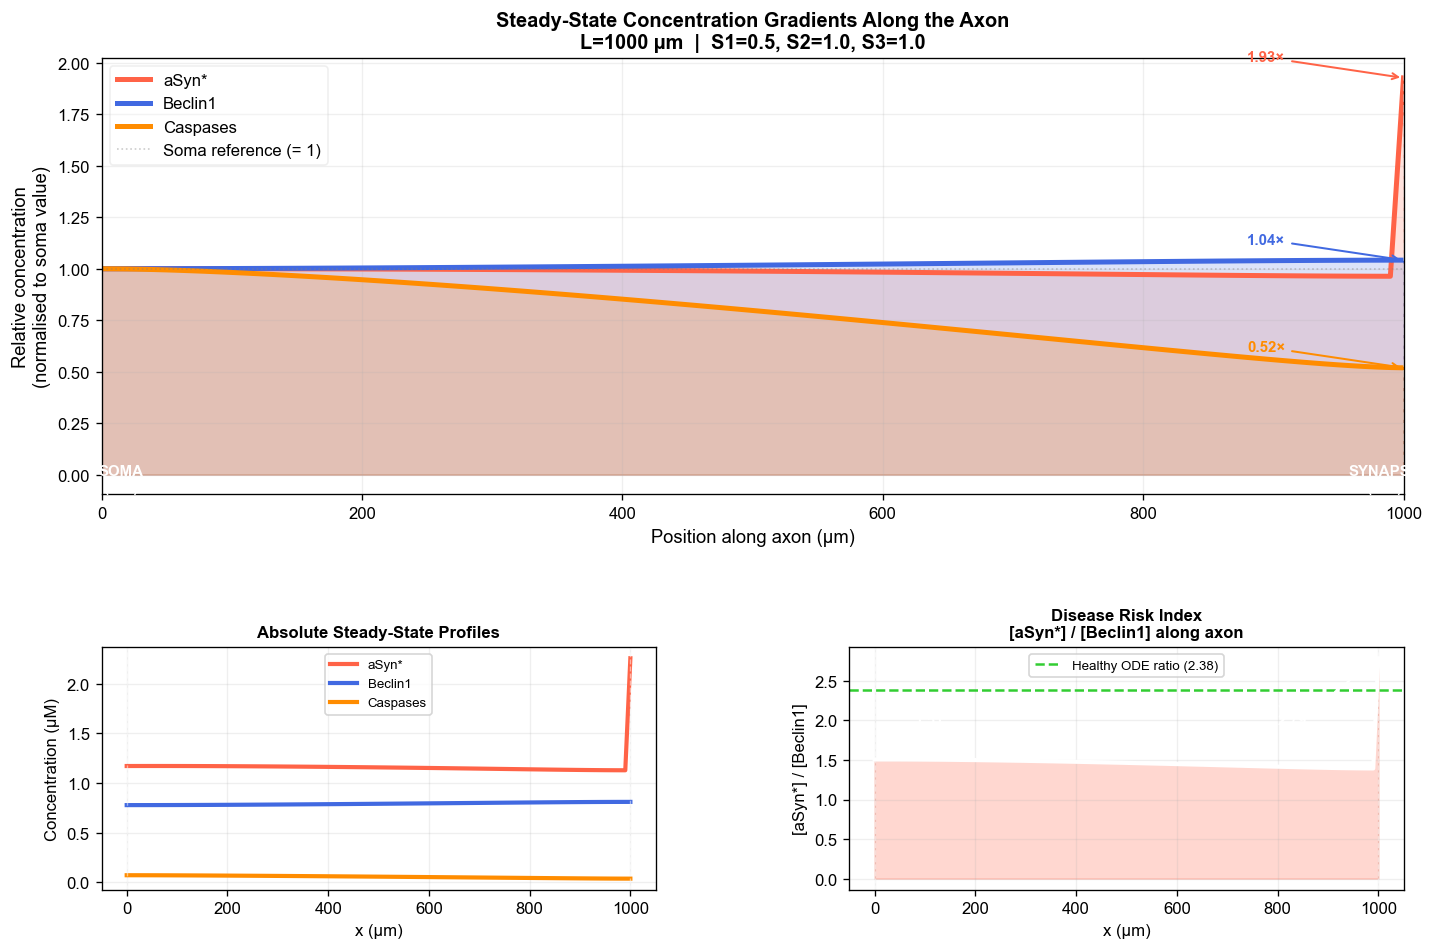


STEADY STATE SUMMARY — L=1000.0 µm
Species             Soma    Mid-axon     Synapse    Syn/Soma
───────────────────────────────────────────────────────
ROS               1.5058      1.5058      1.5058       1.000×
aSyn*             1.1705      1.1566      2.2553       1.927×
ERS               0.7377      0.7334      0.7526       1.020×
mTOR              0.6131      0.6098      0.6109       0.996×
Beclin1           0.7772      0.7907      0.8096       1.042×
Caspases          0.0715      0.0568      0.0371       0.519×

Disease risk index [aSyn*]/[Beclin1]:
  Soma    : 1.5061
  Mid-axon: 1.4626
  Synapse : 2.7857
  Healthy ODE reference: 2.3819
  Synapse risk vs reference: 1.2×


In [27]:
# ── Normalise to soma value for relative comparison ───────────────────────────
def normalise_to_soma(field):
    """Relative concentration: field / field[soma]"""
    return field / (field[0] + 1e-12)

def normalise_to_max(field):
    """Relative concentration: field / max(field)"""
    return field / (field.max() + 1e-12)

A_ss    = SS['aSyn*']
B1_ss   = SS['Beclin1']
Casp_ss = SS['Caspases']

# Relative to soma value
A_rel    = normalise_to_soma(A_ss)
B1_rel   = normalise_to_soma(B1_ss)
Casp_rel = normalise_to_soma(Casp_ss)

# ── Build the graphic ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2,
                        height_ratios=[1.8, 1],
                        hspace=0.45, wspace=0.35)

ax_main  = fig.add_subplot(gs[0, :])   # full-width top panel
ax_abs1  = fig.add_subplot(gs[1, 0])   # bottom left — absolute
ax_abs2  = fig.add_subplot(gs[1, 1])   # bottom right — ratio

# ── Top panel: relative gradients on shared axis ──────────────────────────────
ax_main.fill_between(x, 0, A_rel,
                     alpha=0.18, color='tomato')
ax_main.fill_between(x, 0, B1_rel,
                     alpha=0.18, color='royalblue')
ax_main.fill_between(x, 0, Casp_rel,
                     alpha=0.18, color='darkorange')

ax_main.plot(x, A_rel,    color='tomato',     lw=3,   label='aSyn*')
ax_main.plot(x, B1_rel,   color='royalblue',  lw=3,   label='Beclin1')
ax_main.plot(x, Casp_rel, color='darkorange', lw=3,   label='Caspases')

# Mark soma and synapse
ax_main.axvline(0,   color='white', ls='--', lw=1.2, alpha=0.5)
ax_main.axvline(L,   color='white', ls='--', lw=1.2, alpha=0.5)
ax_main.axhline(1.0, color='gray',  ls=':',  lw=1.0, alpha=0.4,
                label='Soma reference (= 1)')

# Annotate key values at synapse
for val, col, sp in [(A_rel[-1],    'tomato',     'aSyn*'),
                     (B1_rel[-1],   'royalblue',  'Beclin1'),
                     (Casp_rel[-1], 'darkorange', 'Caspases')]:
    ax_main.annotate(f'{val:.2f}×',
                     xy=(L, val),
                     xytext=(L - 120, val + 0.08),
                     fontsize=9, color=col, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=col,
                                     lw=1.2))

# Soma labels
ax_main.text(15,   -0.08,
             'SOMA\n(x=0)',
             ha='center', fontsize=9,
             color='white', fontweight='bold')
ax_main.text(L-15, -0.08,
             'SYNAPSE\n(x=L)',
             ha='center', fontsize=9,
             color='white', fontweight='bold')

ax_main.set_xlabel('Position along axon (µm)', fontsize=11)
ax_main.set_ylabel('Relative concentration\n(normalised to soma value)',
                   fontsize=11)
ax_main.set_title(
    f'Steady-State Concentration Gradients Along the Axon\n'
    f'L={L:.0f} µm  |  S\u2081={CFG["S1"]}, S\u2082={CFG["S2"]}, '
    f'S\u2083={CFG["S3"]}',
    fontsize=12, fontweight='bold'
)
ax_main.legend(fontsize=10, loc='upper left',
               framealpha=0.3)
ax_main.set_xlim(0, L)
ax_main.grid(alpha=0.2)

# ── Bottom left: absolute SS concentrations ───────────────────────────────────
ax_abs1.plot(x, A_ss,    color='tomato',     lw=2.5, label='aSyn*')
ax_abs1.plot(x, B1_ss,   color='royalblue',  lw=2.5, label='Beclin1')
ax_abs1.plot(x, Casp_ss, color='darkorange', lw=2.5, label='Caspases')
ax_abs1.axvline(0, color='white', ls='--', lw=0.8, alpha=0.5)
ax_abs1.axvline(L, color='white', ls='--', lw=0.8, alpha=0.5)
ax_abs1.set_xlabel('x (µm)', fontsize=10)
ax_abs1.set_ylabel('Concentration (µM)', fontsize=10)
ax_abs1.set_title('Absolute Steady-State Profiles',
                  fontsize=10, fontweight='bold')
ax_abs1.legend(fontsize=8)
ax_abs1.grid(alpha=0.2)

# ── Bottom right: aSyn* / Beclin1 ratio (disease risk index) ─────────────────
ratio = A_ss / (B1_ss + 1e-6)
ax_abs2.plot(x, ratio, color='white', lw=2.5)
ax_abs2.fill_between(x, 0, ratio, alpha=0.25, color='tomato')

# Mark threshold lines
healthy_ratio = SS_HEALTHY['aSyn'] / SS_HEALTHY['Beclin1']
ax_abs2.axhline(healthy_ratio, color='limegreen', ls='--', lw=1.5,
                label=f'Healthy ODE ratio ({healthy_ratio:.2f})')

ax_abs2.axvline(0, color='white', ls='--', lw=0.8, alpha=0.5)
ax_abs2.axvline(L, color='white', ls='--', lw=0.8, alpha=0.5)
ax_abs2.set_xlabel('x (µm)', fontsize=10)
ax_abs2.set_ylabel('[aSyn*] / [Beclin1]', fontsize=10)
ax_abs2.set_title('Disease Risk Index\n[aSyn*] / [Beclin1] along axon',
                  fontsize=10, fontweight='bold')
ax_abs2.legend(fontsize=8)
ax_abs2.grid(alpha=0.2)

# Annotate soma and synapse risk values
for xpos, label in [(0, f'Soma\n{ratio[0]:.2f}'),
                    (L, f'Synapse\n{ratio[-1]:.2f}')]:
    ax_abs2.annotate(label,
                     xy=(xpos, ratio[0] if xpos==0 else ratio[-1]),
                     xytext=(xpos + (80 if xpos==0 else -200),
                              ratio[-1]*0.7),
                     fontsize=9, color='white', fontweight='bold',
                     arrowprops=dict(arrowstyle='->',
                                     color='white', lw=1.2))

ax_main.set_title(
    f'Steady-State Concentration Gradients Along the Axon\n'
    f'L={L:.0f} µm  |  S1={CFG["S1"]}, S2={CFG["S2"]}, S3={CFG["S3"]}',
    fontsize=12, fontweight='bold'
)
plt.savefig('axon_gradient_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print SS summary table ────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"STEADY STATE SUMMARY — L={L} µm")
print(f"{'='*65}")
print(f"{'Species':<12}  {'Soma':>10}  {'Mid-axon':>10}  "
      f"{'Synapse':>10}  {'Syn/Soma':>10}")
print(f"{'─'*55}")
for sp in species_names:
    f   = SS[sp]
    rat = f[-1] / (f[0] + 1e-12)
    print(f"{sp:<12}  {f[0]:>10.4f}  {f[Nx//2]:>10.4f}  "
          f"{f[-1]:>10.4f}  {rat:>10.3f}×")

print(f"\nDisease risk index [aSyn*]/[Beclin1]:")
print(f"  Soma    : {ratio[0]:.4f}")
print(f"  Mid-axon: {ratio[Nx//2]:.4f}")
print(f"  Synapse : {ratio[-1]:.4f}")
print(f"  Healthy ODE reference: {healthy_ratio:.4f}")
print(f"  Synapse risk vs reference: {ratio[-1]/healthy_ratio:.1f}×")

In [28]:
# === Check SS aSyn* at synapse for S1 = 0.5, 0.8, 1.0, 1.2, 1.4 ===
# Fast scan using just the boundary point dynamics
# to find which S1 gives synapse near disease threshold

S1_test = [0.5, 0.8, 1.0, 1.1, 1.2, 1.3, 1.4]

print(f"{'S1':>6}  {'aSyn*(soma)':>12}  {'aSyn*(syn)':>12}  "
      f"{'B1*(soma)':>10}  {'B1*(syn)':>10}  "
      f"{'Risk(syn)':>10}  State")
print("─" * 80)

for s1 in S1_test:
    p_test = {**CFG, 'S1': s1}
    y0_t, _ = build_ic(L, Nx, CFG, TR, SS_HEALTHY)

    sol_t = solve_ivp(
        pde_rhs, (0, 500), y0_t,
        args     = (p_test, TR, dx, Nx),
        method   = 'Radau',
        rtol     = 1e-5, atol = 1e-7,
        max_step = 1.0,
        dense_output = False
    )

    A_ss   = sol_t.y[1*Nx:2*Nx, -1]
    B1_ss  = sol_t.y[4*Nx:5*Nx, -1]
    C_ss   = sol_t.y[5*Nx:6*Nx, -1]
    risk   = A_ss[-1] / (B1_ss[-1] + 1e-6)

    # classify synapse state
    if   A_ss[-1] < 3:    state = 'Healthy'
    elif A_ss[-1] < 10:   state = 'Intermediate'
    else:                  state = 'Disease'

    print(f"{s1:>6.2f}  {A_ss[0]:>12.4f}  {A_ss[-1]:>12.4f}  "
          f"{B1_ss[0]:>10.4f}  {B1_ss[-1]:>10.4f}  "
          f"{risk:>10.3f}  {state}")

    S1   aSyn*(soma)    aSyn*(syn)   B1*(soma)    B1*(syn)   Risk(syn)  State
────────────────────────────────────────────────────────────────────────────────
  0.50        1.1705        2.2553      0.7772      0.8096       2.786  Healthy
  0.80        1.3670        2.6228      0.7790      0.8162       3.213  Healthy
  1.00        1.4985        2.8660      0.7791      0.8199       3.496  Healthy
  1.10        1.5645        2.9873      0.7789      0.8215       3.636  Healthy
  1.20        1.6310        3.1087      0.7785      0.8230       3.777  Intermediate
  1.30        1.6978        3.2300      0.7779      0.8245       3.918  Intermediate
  1.40        1.7651        3.3515      0.7772      0.8258       4.058  Intermediate


In [29]:
# === Extended S1 scan — push into tristable territory ===

S1_extended = [1.40, 1.45, 1.462, 1.50, 1.60, 1.80, 2.0]

print(f"{'S1':>6}  {'A*(soma)':>10}  {'A*(syn)':>10}  "
      f"{'B1*(soma)':>10}  {'B1*(syn)':>10}  "
      f"{'Casp*(syn)':>11}  {'Risk(syn)':>10}  State")
print("─" * 90)

for s1 in S1_extended:
    p_test = {**CFG, 'S1': s1}
    y0_t, _ = build_ic(L, Nx, CFG, TR, SS_HEALTHY)

    sol_t = solve_ivp(
        pde_rhs, (0, 800), y0_t,
        args     = (p_test, TR, dx, Nx),
        method   = 'Radau',
        rtol     = 1e-5, atol = 1e-7,
        max_step = 1.0,
    )

    A_ss   = sol_t.y[1*Nx:2*Nx, -1]
    B1_ss  = sol_t.y[4*Nx:5*Nx, -1]
    C_ss   = sol_t.y[5*Nx:6*Nx, -1]
    risk   = A_ss[-1] / (B1_ss[-1] + 1e-6)

    # Check convergence
    A_drift = np.max(np.abs(
        sol_t.y[1*Nx:2*Nx, -1] - sol_t.y[1*Nx:2*Nx, -5]))

    if   A_ss[-1] < 3:    state = 'Healthy      '
    elif A_ss[-1] < 8:    state = 'Intermediate '
    else:                  state = 'DISEASE      '

    drift_flag = '' if A_drift < 0.01 else '  ⚠ drifting'

    print(f"{s1:>6.3f}  {A_ss[0]:>10.4f}  {A_ss[-1]:>10.4f}  "
          f"{B1_ss[0]:>10.4f}  {B1_ss[-1]:>10.4f}  "
          f"{C_ss[-1]:>11.4f}  {risk:>10.3f}  "
          f"{state}{drift_flag}")

    S1    A*(soma)     A*(syn)   B1*(soma)    B1*(syn)   Casp*(syn)   Risk(syn)  State
──────────────────────────────────────────────────────────────────────────────────────────
 1.400      1.7651      3.3515      0.7772      0.8258       0.0443       4.058  Intermediate 
 1.450      1.7989      3.4123      0.7767      0.8265       0.0447       4.129  Intermediate 
 1.462      1.8071      3.4269      0.7766      0.8266       0.0448       4.146  Intermediate 
 1.500      1.8329      3.4732      0.7762      0.8271       0.0450       4.199  Intermediate 
 1.600      1.9014      3.5951      0.7751      0.8283       0.0457       4.341  Intermediate 
 1.800      2.0407      3.8402      0.7724      0.8305       0.0470       4.624  Intermediate 
 2.000      2.1839      4.0874      0.7688      0.8324       0.0482       4.910  Intermediate 


In [33]:
# === Scan Beclin1 IC decay length ===
# Find L_eff_B1 where synapse tips to disease at S1=1.462
# while soma stays healthy

L_eff_scan = [251, 180, 150, 120, 100, 80, 60]

print(f"{'L_eff_B1':>10}  {'B1_IC(syn)':>12}  {'A*(soma)':>10}  "
      f"{'A*(syn)':>10}  {'B1*(syn)':>10}  {'Risk(syn)':>10}  State")
print("─" * 80)

p_scan = {**CFG, 'S1': 1.462}

for leff in L_eff_scan:
    # Build IC with this decay length
    x_loc   = np.linspace(0, L, Nx)
    ROS_ic  = SS_HEALTHY['ROS']    * np.exp(-0.005 * (L - x_loc))
    aSyn_ic = 0.1 * (x_loc / L)
    ERS_ic  = np.zeros(Nx)
    mTOR_ic = np.full(Nx, SS_HEALTHY['mTOR'])
    B1_ic   = SS_HEALTHY['Beclin1'] * np.exp(-x_loc / leff)
    Casp_ic = 0.01 * np.exp(-x_loc / 500.0)
    y0_scan = np.concatenate([ROS_ic, aSyn_ic, ERS_ic,
                              mTOR_ic, B1_ic, Casp_ic])

    B1_ic_syn = B1_ic[-1]   # IC value at synapse

    sol_scan = solve_ivp(
        pde_rhs, (0, 800), y0_scan,
        args     = (p_scan, TR, dx, Nx),
        method   = 'Radau',
        rtol     = 1e-5, atol = 1e-7,
        max_step = 1.0,
    )

    A_ss  = sol_scan.y[1*Nx:2*Nx, -1]
    B1_ss = sol_scan.y[4*Nx:5*Nx, -1]
    risk  = A_ss[-1] / (B1_ss[-1] + 1e-6)

    if   A_ss[-1] < 3:    state = 'Healthy'
    elif A_ss[-1] < 8:    state = 'Intermediate'
    else:                  state = 'DISEASE ←'

    print(f"{leff:>10}  {B1_ic_syn:>12.5f}  {A_ss[0]:>10.4f}  "
          f"{A_ss[-1]:>10.4f}  {B1_ss[-1]:>10.4f}  "
          f"{risk:>10.3f}  {state}")

  L_eff_B1    B1_IC(syn)    A*(soma)     A*(syn)    B1*(syn)   Risk(syn)  State
────────────────────────────────────────────────────────────────────────────────
       251       0.01418      1.8071      3.4269      0.8266       4.146  Intermediate
       180       0.00295      1.8071      3.4269      0.8266       4.146  Intermediate
       150       0.00097      1.8071      3.4269      0.8266       4.146  Intermediate
       120       0.00018      1.8071      3.4269      0.8266       4.146  Intermediate
       100       0.00003      1.8071      3.4269      0.8266       4.146  Intermediate
        80       0.00000      1.8071      3.4269      0.8266       4.146  Intermediate
        60       0.00000      1.8071      3.4269      0.8266       4.146  Intermediate


In [40]:
# === Fix Cell 8: Define yang_ode_pure + robust FP finder ===
# === Cell 8: ODE-based state classifier ===

def get_stable_fps_at_S1(s1, CFG, n_seeds=800):
    """
    Find all stable fixed points of Yang ODE at given S1.
    Returns list of dicts with fp vector and label.
    """
    import warnings
    from scipy.optimize import fsolve
    from scipy.linalg import eigvals as speigvals

    p = {**CFG, 'S1': s1}

    def rhs(y):
        return yang_ode_pure(0, y, p)

    fps = []
    rng = np.random.default_rng(42)
    seeds = rng.uniform(
        low  = [0, 0,  0, 0, 0, 0],
        high = [20, 20, 2, 1, 1, 1],
        size = (n_seeds, 6)
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in seeds:
            try:
                fp, info, ier, _ = fsolve(rhs, s, full_output=True)
                if ier != 1: continue
                if np.max(np.abs(rhs(fp))) > 1e-8: continue
                if np.any(fp < -1e-4): continue
                is_new = all(
                    not np.allclose(fp, e['fp'], atol=1e-3)
                    for e in fps
                )
                if is_new:
                    J      = numerical_jacobian(fp, p)
                    eigs   = speigvals(J)
                    stable = np.max(np.real(eigs)) < 0
                    if stable:
                        fps.append({'fp': fp, 'A': fp[1],
                                    'B1': fp[4], 'C': fp[5]})
            except:
                continue

    # Sort by aSyn* — low to high
    fps = sorted(fps, key=lambda d: d['A'])

    # Label by rank
    labels = ['Healthy', 'Intermediate', 'Disease']
    for i, fp_dict in enumerate(fps):
        fp_dict['label'] = labels[i] if i < 3 else f'State{i}'

    return fps


def normalized_distance(point, fp_dict, weights=None):
    """
    Compute normalized Euclidean distance between a spatial point
    [aSyn*, Beclin1, Caspases] and a fixed point.

    Normalization: divide each variable by its range across all FPs
    so all variables contribute equally regardless of scale.

    point   : array [aSyn*, Beclin1, Caspases] at one grid location
    fp_dict : dict with keys 'A', 'B1', 'C'
    weights : optional [w_A, w_B1, w_C] — default equal weights
    """
    if weights is None:
        weights = np.array([1.0, 1.0, 1.0])

    ref = np.array([fp_dict['A'], fp_dict['B1'], fp_dict['C']])
    diff = (point - ref) * weights
    return np.sqrt(np.sum(diff**2))


def classify_axon_profile(A_ss, B1_ss, C_ss, stable_fps,
                           normalize=True):
    """
    Classify state at every grid point along the axon.

    Uses normalized distance to each stable FP in the
    [aSyn*, Beclin1, Caspases] subspace.

    Returns:
        state_labels : list of strings, one per grid point
        state_indices: integer array (0=healthy,1=interm,2=disease)
        distances    : (Nx, n_fps) array of distances to each FP
        confidence   : (Nx,) array — gap between nearest and 2nd nearest
    """
    Nx = len(A_ss)
    n_fps = len(stable_fps)

    # Compute normalization factors from FP range
    A_vals  = np.array([f['A']  for f in stable_fps])
    B1_vals = np.array([f['B1'] for f in stable_fps])
    C_vals  = np.array([f['C']  for f in stable_fps])

    if normalize:
        A_range  = max(A_vals.max()  - A_vals.min(),  1e-6)
        B1_range = max(B1_vals.max() - B1_vals.min(), 1e-6)
        C_range  = max(C_vals.max()  - C_vals.min(),  1e-6)
        weights  = np.array([1/A_range, 1/B1_range, 1/C_range])
    else:
        weights = np.array([1.0, 1.0, 1.0])

    # Distance from each grid point to each FP
    distances    = np.zeros((Nx, n_fps))
    for j in range(Nx):
        point = np.array([A_ss[j], B1_ss[j], C_ss[j]])
        for k, fp_dict in enumerate(stable_fps):
            distances[j, k] = normalized_distance(
                point, fp_dict, weights
            )

    # Classify by nearest FP
    nearest_idx  = np.argmin(distances, axis=1)
    state_labels = [stable_fps[i]['label'] for i in nearest_idx]
    state_indices = nearest_idx.copy()

    # Confidence: gap between nearest and second nearest distance
    sorted_d   = np.sort(distances, axis=1)
    confidence = sorted_d[:, 1] - sorted_d[:, 0]  # larger = more certain

    return state_labels, state_indices, distances, confidence


# ── Get stable FPs at operating S1 ───────────────────────────────────────────
print("Finding stable fixed points at S1=1.462...")
stable_fps = get_stable_fps_at_S1(1.462, CFG)

print(f"\nFound {len(stable_fps)} stable fixed points:")
print(f"{'Label':<16}  {'aSyn*':>8}  {'Beclin1':>8}  "
      f"{'Caspases':>10}")
print("─" * 48)
for fp in stable_fps:
    print(f"{fp['label']:<16}  {fp['A']:>8.4f}  "
          f"{fp['B1']:>8.4f}  {fp['C']:>10.4f}")
def yang_ode_pure(t, y, p):
    """Yang ODE — no spatial terms."""
    ROS, A, ERS, mTOR, B1, Casp = [max(v, 0.0) for v in y]
    Hill  = (A/p['K'])**p['n'] / (1 + (A/p['K'])**p['n'])
    dROS  = p['k1']*(1+p['S1']+p['d_aSyn']*Hill) - p['k2']*ROS*p['S2']
    dA    = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR
    dERS  = p['k6']*A*p['k7']*(p['ERST']-ERS) - p['k8']*ERS
    MT    = p['mTORT']
    dM    = (p['k9']+p['k10']*ERS)*(MT-mTOR) - (p['k11']+p['k12']*B1)*mTOR
    BT    = p['Beclin1T']
    act_B = (p['k13']+p['k14']*ERS)*(BT-B1)/(p['Jbe']+BT-B1+1e-12)
    inh_B = (p['k15']+p['k16']*Casp+p['k17']*mTOR)*B1/(p['Jbe']+B1+1e-12)
    dB1   = act_B - inh_B
    CT    = p['CaspasesT']
    act_C = (p['k18']+p['k19']*ERS+p['k20']*mTOR)*(CT-Casp)/(p['Jca']+CT-Casp+1e-12)
    inh_C = (p['k21']+p['k22']*B1)*Casp/(p['Jca']+Casp+1e-12)
    dCasp = act_C - inh_C
    return [dROS, dA, dERS, dM, dB1, dCasp]


def numerical_jacobian(fp, p, eps=1e-6):
    n  = len(fp)
    J  = np.zeros((n, n))
    f0 = np.array(yang_ode_pure(0, fp, p))
    for j in range(n):
        yp = fp.copy(); yp[j] += eps
        J[:, j] = (np.array(yang_ode_pure(0, yp, p)) - f0) / eps
    return J


def get_stable_fps_at_S1(s1, CFG, n_seeds=1000):
    """
    Find stable FPs at given S1.
    Falls back gracefully if fewer than 3 found.
    """
    from scipy.optimize import fsolve
    from scipy.linalg import eigvals as speigvals
    import warnings

    p = {**CFG, 'S1': s1}
    def rhs(y): return yang_ode_pure(0, y, p)

    fps = []
    rng = np.random.default_rng(42)
    seeds = rng.uniform(
        low  = [0, 0,  0, 0, 0, 0],
        high = [20, 20, 2, 1, 1, 1],
        size = (n_seeds, 6)
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in seeds:
            try:
                fp, info, ier, _ = fsolve(rhs, s, full_output=True)
                if ier != 1: continue
                if np.max(np.abs(rhs(fp))) > 1e-8: continue
                if np.any(fp < -1e-4): continue
                is_new = all(
                    not np.allclose(fp, e['fp'], atol=1e-3)
                    for e in fps
                )
                if is_new:
                    J      = numerical_jacobian(fp, p)
                    eigs   = speigvals(J)
                    stable = np.max(np.real(eigs)) < 0
                    if stable:
                        fps.append({
                            'fp': fp,
                            'A':  fp[1],
                            'B1': fp[4],
                            'C':  fp[5]
                        })
            except:
                continue

    # Sort by aSyn*
    fps = sorted(fps, key=lambda d: d['A'])

    # Label
    labels = ['Healthy', 'Intermediate', 'Disease']
    for i, fp_dict in enumerate(fps):
        fp_dict['label'] = labels[i] if i < len(labels) else f'State{i}'

    return fps


# ── Find FPs — use S1=1.462 (tristable window) as reference ──────────────────
# IMPORTANT: use S1=1.462 for FP references regardless of simulation S1
# This gives you all three attractor signatures for classification
print("Finding stable FPs at S1=1.462 (tristable reference)...")
stable_fps = get_stable_fps_at_S1(1.462, CFG)

print(f"\nFound {len(stable_fps)} stable FP(s):")
print(f"{'Label':<16}  {'aSyn*':>8}  {'Beclin1':>8}  {'Caspases':>10}")
print("─" * 50)
for fp in stable_fps:
    print(f"  {fp['label']:<14}  {fp['A']:>8.4f}  "
          f"{fp['B1']:>8.4f}  {fp['C']:>10.4f}")

# ── Handle case where fewer than 3 FPs found ─────────────────────────────────
if len(stable_fps) == 0:
    raise ValueError(
        "No stable FPs found at S1=1.462. "
        "Check yang_ode_pure and CFG parameters."
    )
elif len(stable_fps) == 1:
    print("\n⚠ Only 1 stable FP found — system is monostable at S1=1.462")
    print("  Classification will only distinguish 'Healthy' vs 'other'")
elif len(stable_fps) == 2:
    print("\n⚠ Only 2 stable FPs found — system is bistable at S1=1.462")
    print("  Try n_seeds=2000 or check S1 value")
else:
    print("\n✓ All 3 stable FPs found — tristable classification ready")

Finding stable fixed points at S1=1.462...

Found 3 stable fixed points:
Label                aSyn*   Beclin1    Caspases
────────────────────────────────────────────────
Healthy             1.8150    0.7621      0.1179
Intermediate        3.7083    0.3558      0.9243
Disease            16.4825    0.4343      0.9388
Finding stable FPs at S1=1.462 (tristable reference)...

Found 3 stable FP(s):
Label                aSyn*   Beclin1    Caspases
──────────────────────────────────────────────────
  Healthy           1.8150    0.7621      0.1179
  Intermediate      3.7083    0.3558      0.9243
  Disease          16.4825    0.4343      0.9388

✓ All 3 stable FPs found — tristable classification ready


In [46]:
# === Rerun at S1=1.462 — puts synapse in intermediate basin ===

CFG['S1'] = 1.462

# Rebuild IC with updated CFG
y0, x = build_ic(L, Nx, CFG, TR, SS_HEALTHY)

# Rerun PDE
t_eval = np.unique(np.concatenate([
    np.linspace(0,   10,  50),
    np.linspace(10,  100, 100),
    np.linspace(100, 500, 100),
]))

print(f"Rerunning at S1={CFG['S1']}...")
t0  = time.time()
sol = solve_ivp(
    pde_rhs, (0, 500), y0,
    args        = (CFG, TR, dx, Nx),
    method      = 'Radau',
    t_eval      = t_eval,
    rtol        = 1e-5, atol = 1e-7,
    max_step    = 1.0,
)
print(f"Done in {time.time()-t0:.1f}s. Success={sol.success}")

# Update SS dict
SS = {}
for i, sp in enumerate(species_names):
    SS[sp] = sol.y[i*Nx:(i+1)*Nx, -1]
    drift  = np.max(np.abs(
        sol.y[i*Nx:(i+1)*Nx,-1] - sol.y[i*Nx:(i+1)*Nx,-5]
    ))
    print(f"  {sp:<12}: synapse SS = {SS[sp][-1]:.4f} µM  "
          f"drift={drift:.2e}  "
          f"{'✓' if drift<1e-3 else '⚠'}")

# Quick classification preview
A_ss  = SS['aSyn*']
B1_ss = SS['Beclin1']
C_ss  = SS['Caspases']

print(f"\nQuick check:")
print(f"  aSyn*(soma)    = {A_ss[0]:.4f} µM")
print(f"  aSyn*(synapse) = {A_ss[-1]:.4f} µM")
print(f"  Healthy FP     = 1.8150 µM")
print(f"  Midpoint H↔I   = 2.7617 µM")
print(f"  Intermediate FP= 3.7083 µM")
dist_H = abs(A_ss[-1] - 1.815)
dist_I = abs(A_ss[-1] - 3.708)
print(f"  Synapse closer to: "
      f"{'Intermediate ←' if dist_I < dist_H else 'Healthy'}")

Rerunning at S1=1.462...
Done in 6.8s. Success=True
  ROS         : synapse SS = 2.4937 µM  drift=4.44e-16  ✓
  aSyn*       : synapse SS = 3.4269 µM  drift=2.22e-16  ✓
  ERS         : synapse SS = 0.9596 µM  drift=1.11e-16  ✓
  mTOR        : synapse SS = 0.6521 µM  drift=1.11e-16  ✓
  Beclin1     : synapse SS = 0.8266 µM  drift=1.11e-16  ✓
  Caspases    : synapse SS = 0.0448 µM  drift=2.78e-17  ✓

Quick check:
  aSyn*(soma)    = 1.8071 µM
  aSyn*(synapse) = 3.4269 µM
  Healthy FP     = 1.8150 µM
  Midpoint H↔I   = 2.7617 µM
  Intermediate FP= 3.7083 µM
  Synapse closer to: Intermediate ←


In [47]:
# === Cell 9: Classify every grid point along the axon ===

# Extract SS fields
A_ss    = SS['aSyn*']
B1_ss   = SS['Beclin1']
C_ss    = SS['Caspases']

# Classify
state_labels, state_idx, distances, confidence = classify_axon_profile(
    A_ss, B1_ss, C_ss, stable_fps
)

# ── Print spatial state profile ───────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"SPATIAL STATE CLASSIFICATION — L={L} µm, S1={CFG['S1']}")
print(f"{'='*75}")
print(f"\n{'x (µm)':>8}  {'aSyn*':>8}  {'Beclin1':>8}  "
      f"{'Caspases':>10}  {'State':>16}  {'Confidence':>12}")
print("─" * 70)

# Print at 10 representative positions
for j in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]:
    print(f"{x[j]:>8.1f}  {A_ss[j]:>8.4f}  {B1_ss[j]:>8.4f}  "
          f"{C_ss[j]:>10.4f}  {state_labels[j]:>16}  "
          f"{confidence[j]:>12.4f}")

# ── Count grid points in each state ──────────────────────────────────────────
from collections import Counter
state_counts = Counter(state_labels)
print(f"\nState distribution across {Nx} grid points:")
for lbl, count in state_counts.items():
    pct = count / Nx * 100
    bar = '█' * int(pct / 2)
    print(f"  {lbl:<16}: {count:>4} pts ({pct:>5.1f}%)  {bar}")

# ── Find transition point ─────────────────────────────────────────────────────
transitions = []
for j in range(1, Nx):
    if state_labels[j] != state_labels[j-1]:
        transitions.append((x[j], state_labels[j-1], state_labels[j]))

if transitions:
    print(f"\nState transitions along axon:")
    for xpos, from_s, to_s in transitions:
        print(f"  x = {xpos:.1f} µm: {from_s} → {to_s}")
else:
    print(f"\nNo state transitions — entire axon in: {state_labels[0]}")


SPATIAL STATE CLASSIFICATION — L=1000.0 µm, S1=1.462

  x (µm)     aSyn*   Beclin1    Caspases             State    Confidence
──────────────────────────────────────────────────────────────────────
     0.0    1.8071    0.7766      0.1061           Healthy        1.4048
   101.0    1.8070    0.7781      0.1035           Healthy        1.4049
   202.0    1.8020    0.7820      0.0981           Healthy        1.4049
   303.0    1.7936    0.7873      0.0914           Healthy        1.4047
   404.0    1.7829    0.7935      0.0840           Healthy        1.4042
   505.1    1.7708    0.8000      0.0764           Healthy        1.4037
   606.1    1.7578    0.8068      0.0688           Healthy        1.4031
   707.1    1.7441    0.8133      0.0614           Healthy        1.4025
   808.1    1.7305    0.8195      0.0544           Healthy        1.4021
   909.1    1.7187    0.8245      0.0482           Healthy        1.4018
  1000.0    3.4269    0.8266      0.0448           Healthy        1.365

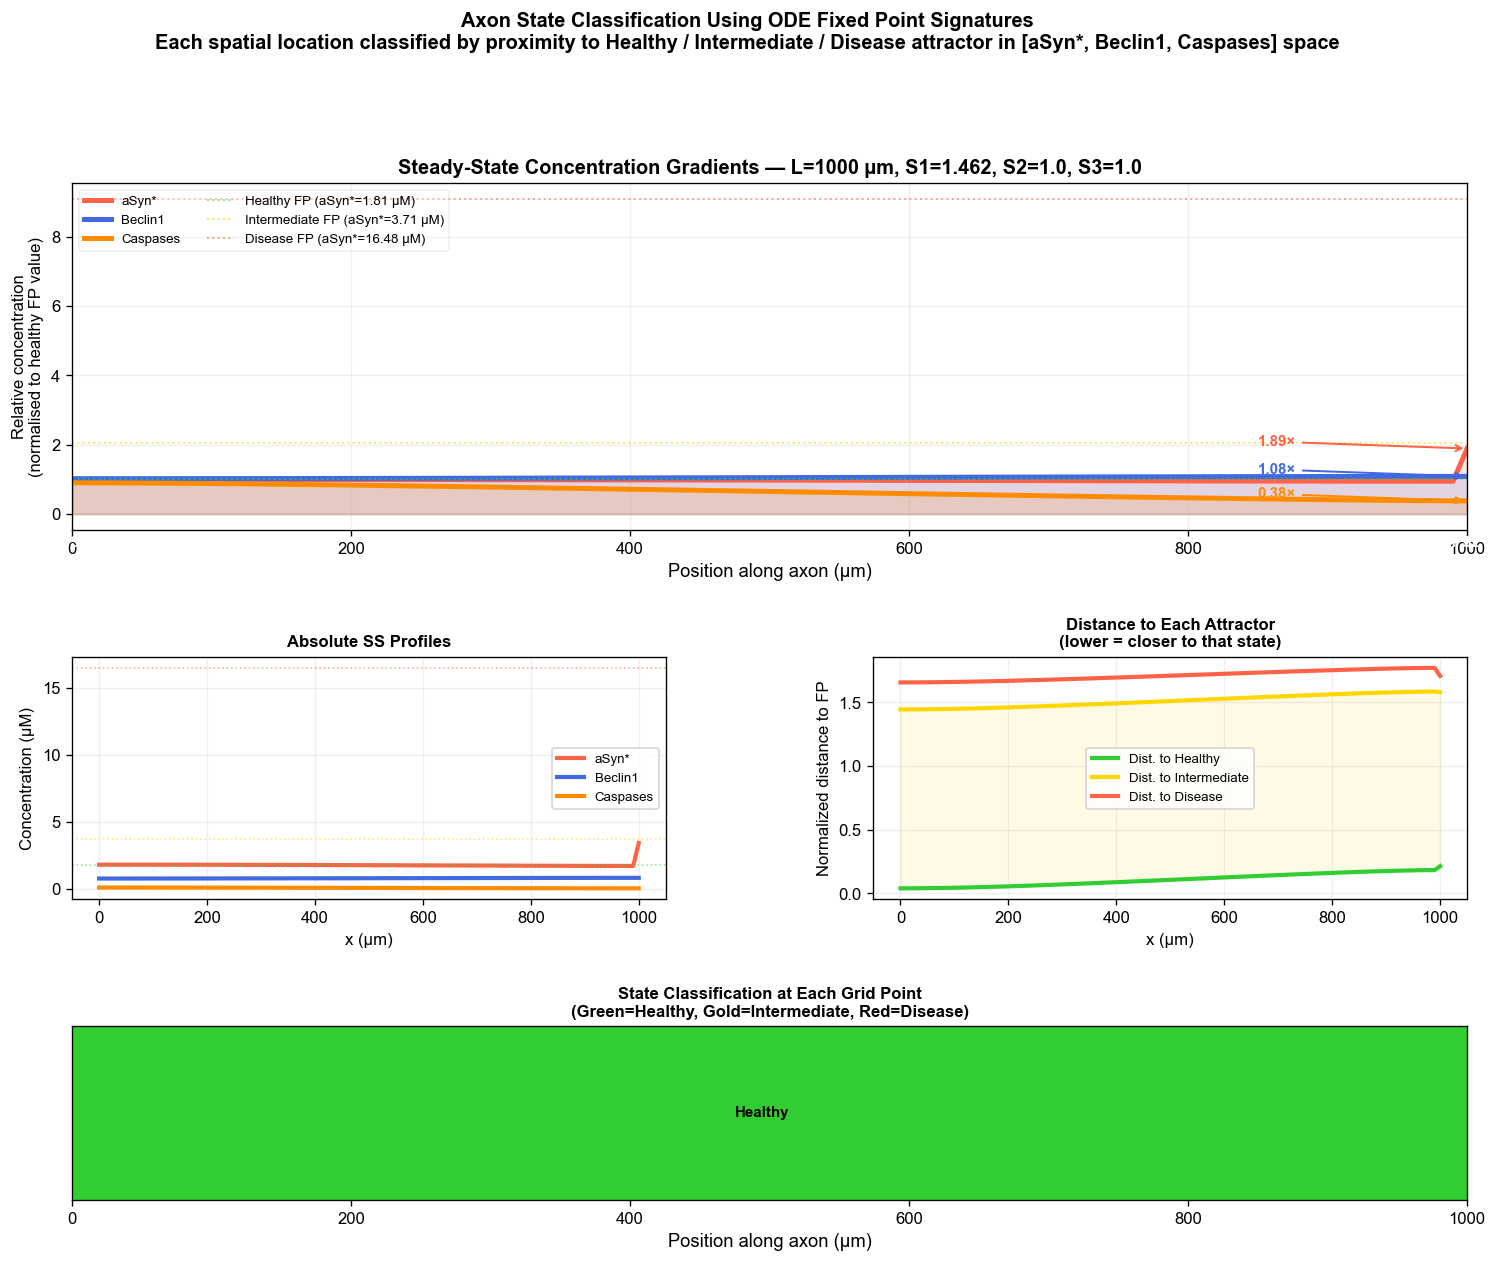


CLASSIFICATION SUMMARY — L=1000.0 µm, S1=1.462

Fixed point references used:
  Healthy         : aSyn*=1.8150  B1=0.7621  Casp=0.1179
  Intermediate    : aSyn*=3.7083  B1=0.3558  Casp=0.9243
  Disease         : aSyn*=16.4825  B1=0.4343  Casp=0.9388

Spatial state distribution:
  Healthy         : 100 pts | x = 0–1000 µm

Key spatial values:
  aSyn*(soma)    = 1.8071 µM  [FP ref: 1.8150]
  aSyn*(synapse) = 3.4269 µM  [FP ref: 1.8150 H / 3.7083 I]
  B1*(soma)      = 0.7766 µM
  B1*(synapse)   = 0.8266 µM

  → Soma in    : Healthy
  → Synapse in : Healthy


In [48]:
# === Cell 10: Gradient figure with state classification ===

state_colors_map = {
    'Healthy':      'limegreen',
    'Intermediate': 'gold',
    'Disease':      'tomato',
}
state_numeric = {'Healthy': 0, 'Intermediate': 1, 'Disease': 2}

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(3, 2,
                        height_ratios=[2.0, 1.4, 1.0],
                        hspace=0.5, wspace=0.35)

ax_grad   = fig.add_subplot(gs[0, :])    # top: relative gradients
ax_abs    = fig.add_subplot(gs[1, 0])    # mid left: absolute
ax_risk   = fig.add_subplot(gs[1, 1])    # mid right: risk index
ax_state  = fig.add_subplot(gs[2, :])    # bottom: state strip

# ── Normalize to FP values for meaningful comparison ─────────────────────────
# Each species normalized by its healthy FP value
A_healthy  = stable_fps[0]['A']
B1_healthy = stable_fps[0]['B1']
C_healthy  = stable_fps[0]['C']

A_rel  = A_ss  / A_healthy
B1_rel = B1_ss / B1_healthy
C_rel  = C_ss  / C_healthy

# Also draw FP reference lines
for fp in stable_fps:
    col   = state_colors_map[fp['label']]
    A_ref = fp['A']  / A_healthy
    B_ref = fp['B1'] / B1_healthy
    C_ref = fp['C']  / C_healthy

# ── TOP: relative gradients ───────────────────────────────────────────────────
ax_grad.fill_between(x, 0, A_rel,
                     alpha=0.15, color='tomato')
ax_grad.fill_between(x, 0, B1_rel,
                     alpha=0.15, color='royalblue')
ax_grad.fill_between(x, 0, C_rel,
                     alpha=0.15, color='darkorange')

ax_grad.plot(x, A_rel,  color='tomato',     lw=3,
             label='aSyn*')
ax_grad.plot(x, B1_rel, color='royalblue',  lw=3,
             label='Beclin1')
ax_grad.plot(x, C_rel,  color='darkorange', lw=3,
             label='Caspases')

# Draw FP reference lines for all three states
for fp in stable_fps:
    col  = state_colors_map[fp['label']]
    yref = fp['A'] / A_healthy
    ax_grad.axhline(yref, color=col, ls=':', lw=1.2,
                    alpha=0.6, label=f'{fp["label"]} FP '
                    f'(aSyn*={fp["A"]:.2f} µM)')

# Annotate synapse values
for val, label, col, offset in [
    (A_rel[-1],  f'{A_rel[-1]:.2f}×',  'tomato',     0.08),
    (B1_rel[-1], f'{B1_rel[-1]:.2f}×', 'royalblue',  0.08),
    (C_rel[-1],  f'{C_rel[-1]:.2f}×',  'darkorange', 0.08),
]:
    ax_grad.annotate(label,
                     xy=(L, val),
                     xytext=(L - 150, val + offset),
                     fontsize=9, color=col, fontweight='bold',
                     arrowprops=dict(arrowstyle='->',
                                     color=col, lw=1.2))

ax_grad.set_xlabel('Position along axon (µm)', fontsize=11)
ax_grad.set_ylabel('Relative concentration\n'
                   '(normalised to healthy FP value)',
                   fontsize=10)
ax_grad.set_title(
    f'Steady-State Concentration Gradients — '
    f'L={L:.0f} µm, S1={CFG["S1"]}, S2={CFG["S2"]}, S3={CFG["S3"]}',
    fontsize=12, fontweight='bold'
)
ax_grad.legend(fontsize=8, loc='upper left', framealpha=0.3,
               ncol=2)
ax_grad.set_xlim(0, L)
ax_grad.grid(alpha=0.2)
ax_grad.text(15,   -0.05, 'SOMA',    ha='center',
             fontsize=9, color='white', fontweight='bold',
             transform=ax_grad.get_xaxis_transform())
ax_grad.text(L-15, -0.05, 'SYNAPSE', ha='center',
             fontsize=9, color='white', fontweight='bold',
             transform=ax_grad.get_xaxis_transform())

# ── MID LEFT: absolute SS profiles ───────────────────────────────────────────
ax_abs.plot(x, A_ss,  color='tomato',     lw=2.5, label='aSyn*')
ax_abs.plot(x, B1_ss, color='royalblue',  lw=2.5, label='Beclin1')
ax_abs.plot(x, C_ss,  color='darkorange', lw=2.5, label='Caspases')

# Mark FP values as horizontal references
for fp in stable_fps:
    col = state_colors_map[fp['label']]
    ax_abs.axhline(fp['A'],  color=col, ls=':', lw=1, alpha=0.5)

ax_abs.set_xlabel('x (µm)', fontsize=10)
ax_abs.set_ylabel('Concentration (µM)', fontsize=10)
ax_abs.set_title('Absolute SS Profiles', fontsize=10,
                 fontweight='bold')
ax_abs.legend(fontsize=8)
ax_abs.grid(alpha=0.2)

# ── MID RIGHT: distance to each FP ───────────────────────────────────────────
for k, fp in enumerate(stable_fps):
    col = state_colors_map[fp['label']]
    ax_risk.plot(x, distances[:, k], color=col, lw=2.5,
                 label=f'Dist. to {fp["label"]}')

ax_risk.fill_between(x,
                     distances[:, 0],
                     distances[:, 1] if len(stable_fps) > 1 else distances[:, 0],
                     alpha=0.1, color='gold')

ax_risk.set_xlabel('x (µm)', fontsize=10)
ax_risk.set_ylabel('Normalized distance to FP', fontsize=10)
ax_risk.set_title('Distance to Each Attractor\n'
                  '(lower = closer to that state)',
                  fontsize=10, fontweight='bold')
ax_risk.legend(fontsize=8)
ax_risk.grid(alpha=0.2)

# ── BOTTOM: state strip ───────────────────────────────────────────────────────
state_numeric_arr = np.array([state_numeric.get(s, 1)
                               for s in state_labels])

# Color each grid cell by its state
from matplotlib.colors import ListedColormap
cmap_state = ListedColormap(['limegreen', 'gold', 'tomato'])

ax_state.imshow(
    state_numeric_arr.reshape(1, -1),
    aspect='auto',
    extent=[0, L, 0, 1],
    cmap=cmap_state,
    vmin=0, vmax=2,
    interpolation='nearest'
)

# Overlay confidence as transparency indicator
ax_state.set_yticks([])
ax_state.set_xlabel('Position along axon (µm)', fontsize=11)
ax_state.set_title('State Classification at Each Grid Point\n'
                   '(Green=Healthy, Gold=Intermediate, Red=Disease)',
                   fontsize=10, fontweight='bold')
ax_state.set_xlim(0, L)

# Annotate state regions
prev_state = state_labels[0]
start_x    = x[0]
for j in range(1, Nx):
    if state_labels[j] != prev_state or j == Nx - 1:
        mid_x = (start_x + x[j-1]) / 2
        ax_state.text(mid_x, 0.5, prev_state,
                      ha='center', va='center',
                      fontsize=9, fontweight='bold',
                      color='black')
        start_x   = x[j]
        prev_state = state_labels[j]

# Mark transition lines
for xpos, from_s, to_s in transitions:
    ax_state.axvline(xpos, color='white', lw=2, ls='--')
    ax_state.text(xpos, 0.85,
                  f'{xpos:.0f}µm',
                  ha='center', fontsize=8,
                  color='white', fontweight='bold')

plt.suptitle(
    'Axon State Classification Using ODE Fixed Point Signatures\n'
    'Each spatial location classified by proximity to '
    'Healthy / Intermediate / Disease attractor in '
    '[aSyn*, Beclin1, Caspases] space',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('axon_state_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"CLASSIFICATION SUMMARY — L={L} µm, S1={CFG['S1']}")
print(f"{'='*65}")
print(f"\nFixed point references used:")
for fp in stable_fps:
    print(f"  {fp['label']:<16}: aSyn*={fp['A']:.4f}  "
          f"B1={fp['B1']:.4f}  Casp={fp['C']:.4f}")

print(f"\nSpatial state distribution:")
for lbl, count in state_counts.items():
    x_range = [x[j] for j in range(Nx) if state_labels[j] == lbl]
    if x_range:
        print(f"  {lbl:<16}: {count:>3} pts | "
              f"x = {min(x_range):.0f}–{max(x_range):.0f} µm")

print(f"\nKey spatial values:")
print(f"  aSyn*(soma)    = {A_ss[0]:.4f} µM  "
      f"[FP ref: {stable_fps[0]['A']:.4f}]")
print(f"  aSyn*(synapse) = {A_ss[-1]:.4f} µM  "
      f"[FP ref: {stable_fps[0]['A']:.4f} H / "
      f"{stable_fps[1]['A']:.4f} I]")
print(f"  B1*(soma)      = {B1_ss[0]:.4f} µM")
print(f"  B1*(synapse)   = {B1_ss[-1]:.4f} µM")
print(f"\n  → Soma in    : {state_labels[0]}")
print(f"  → Synapse in : {state_labels[-1]}")